In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os
from sklearn.model_selection import KFold
import datetime

In [4]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [5]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [6]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [7]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [8]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0006", "B0007"]
test_file = "B0018"

In [9]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [10]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [13]:
from tensorflow.keras.layers import Bidirectional
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN-BiLSTM model
    model = Sequential([
        # First CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                        input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Second CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # 🔹 Replace LSTM with Bidirectional LSTM
        Bidirectional(LSTM(64, return_sequences=False, activation='relu')),
        
        # Dense output layer
        Dense(1)
    ])
    
    # Reshape input data for CNN-BiLSTM
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate on test set
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (498, 2, 4)
Combined target data shape: (498,)
Test data shape: (130, 2, 4)

Training on fold 1
Epoch 1/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 17s 240ms/step - loss: 0.2209 - val_loss: 0.0562
Epoch 2/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0482 - val_loss: 0.0216
Epoch 3/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.0228 - val_loss: 0.0108
Epoch 4/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.0078 - val_loss: 0.0020
Epoch 5/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.0019 - val_loss: 0.0013
Epoch 6/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.0015 - val_loss: 7.5158e-04
Epoch 7/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 9.6634e-04 - val_loss: 4.5905e-04
Epoch 8/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - loss: 7.6285e-04 - val_loss: 4.2145e-04
Epoch 9/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 7.1760e-04 - val_loss: 3.7297e-04
Epoch 10/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss:

In [14]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0034603223
Mean Squared Error (MSE): 0.0000300880
Root Mean Squared Error (RMSE): 0.0054852543
R2 Score: 0.9947322
Mean Absolute Percentage Error (MAPE): 0.4414098%


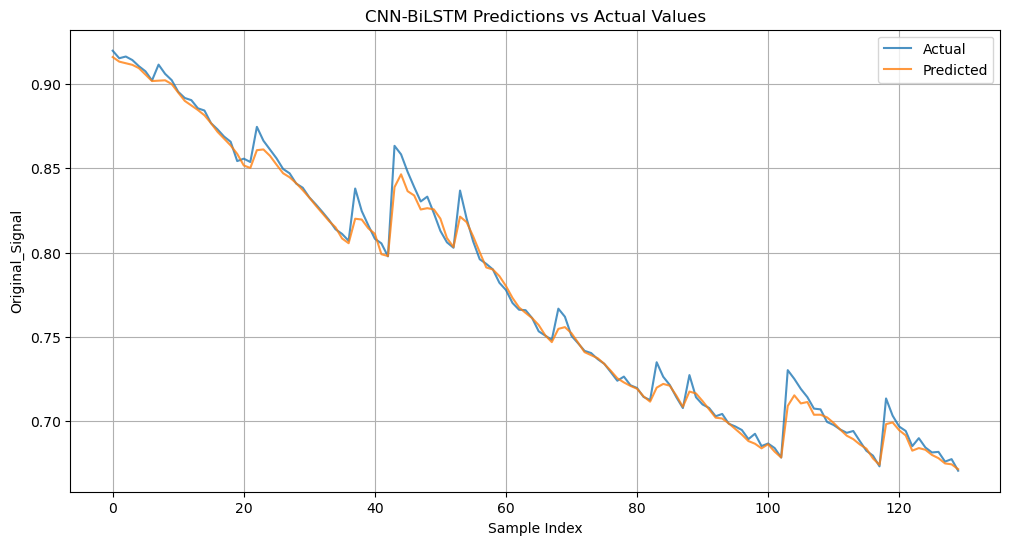


Output shapes:
Actual values shape: (130,)
Predicted values shape: (130,)


In [16]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-BiLSTM Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [17]:
# Save results
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test_actual,
    'Predicted': y_pred_actual,
    'Error': y_test_actual - y_pred_actual
})
predictions_filename = f'CNN_lstm_predictions_{test_file}_{timestamp}.csv'
predictions_df.to_csv(predictions_filename, index=True)
    
    # Save metrics
metrics_df = pd.DataFrame({
    'Metric': ['Test Loss', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE'],
    'Value': [test_loss, mae, mse, rmse, r2, mape]
})
metrics_filename = f'CNN_bilstm_metrics_{test_file}_{timestamp}.csv'
metrics_df.to_csv(metrics_filename, index=False)

In [2]:
#B0005

In [3]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'


In [4]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [5]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data

In [6]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [7]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0018", "B0006", "B0007"]
test_file = "B0005"

In [8]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)


In [9]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [10]:
from tensorflow.keras.layers import Bidirectional
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN-BiLSTM model
    model = Sequential([
        # First CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                        input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Second CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # 🔹 Replace LSTM with Bidirectional LSTM
        Bidirectional(LSTM(64, return_sequences=False, activation='relu')),
        
        # Dense output layer
        Dense(1)
    ])
    
    # Reshape input data for CNN-BiLSTM
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate on test set
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 194ms/step - loss: 0.1586 - val_loss: 0.0368
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0440 - val_loss: 0.0228
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0185 - val_loss: 0.0068
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0052 - val_loss: 0.0016
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0022 - val_loss: 0.0016
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0016 - val_loss: 8.8397e-04
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0012 - val_loss: 8.3278e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0011 - val_loss: 7.3688e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 9.8154e-04 - val_loss: 6.4919e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 8.7307e-04 - val_loss: 5.6609e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 7.9757e-04 - val_loss: 5.2077e-04
Epo

In [11]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0019106330
Mean Squared Error (MSE): 0.0000069574
Root Mean Squared Error (RMSE): 0.0026376966
R2 Score: 0.9992167
Mean Absolute Percentage Error (MAPE): 0.2447168%


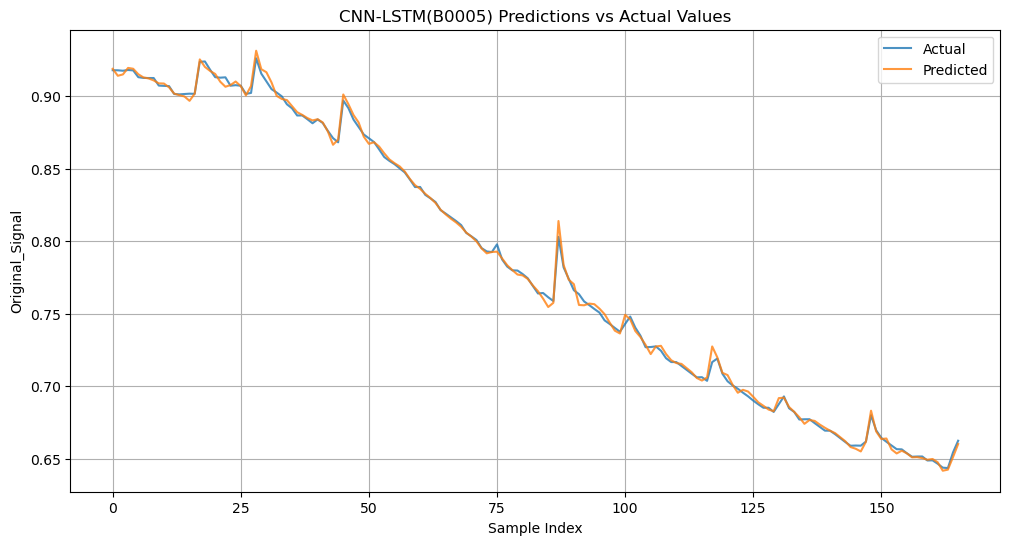


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [12]:
#Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-LSTM(B0005) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [13]:
#B0006

In [14]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [15]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [16]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data

In [17]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [18]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0018", "B0007"]
test_file = "B0006"

In [19]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [20]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [21]:
from tensorflow.keras.layers import Bidirectional
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN-BiLSTM model
    model = Sequential([
        # First CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                        input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Second CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # 🔹 Replace LSTM with Bidirectional LSTM
        Bidirectional(LSTM(64, return_sequences=False, activation='relu')),
        
        # Dense output layer
        Dense(1)
    ])
    
    # Reshape input data for CNN-BiLSTM
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate on test set
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 183ms/step - loss: 0.1638 - val_loss: 0.0348
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0462 - val_loss: 0.0279
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0201 - val_loss: 0.0072
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0063 - val_loss: 0.0025
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.0014 - val_loss: 0.0018
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 9.4202e-04 - val_loss: 0.0012
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 8.6508e-04 - val_loss: 0.0011
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 7.9248e-04 - val_loss: 9.4357e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 7.1179e-04 - val_loss: 8.9207e-04
Epoch 12/1000
1

In [22]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0032208410
Mean Squared Error (MSE): 0.0000199532
Root Mean Squared Error (RMSE): 0.0044668976
R2 Score: 0.9986928
Mean Absolute Percentage Error (MAPE): 0.4166235%


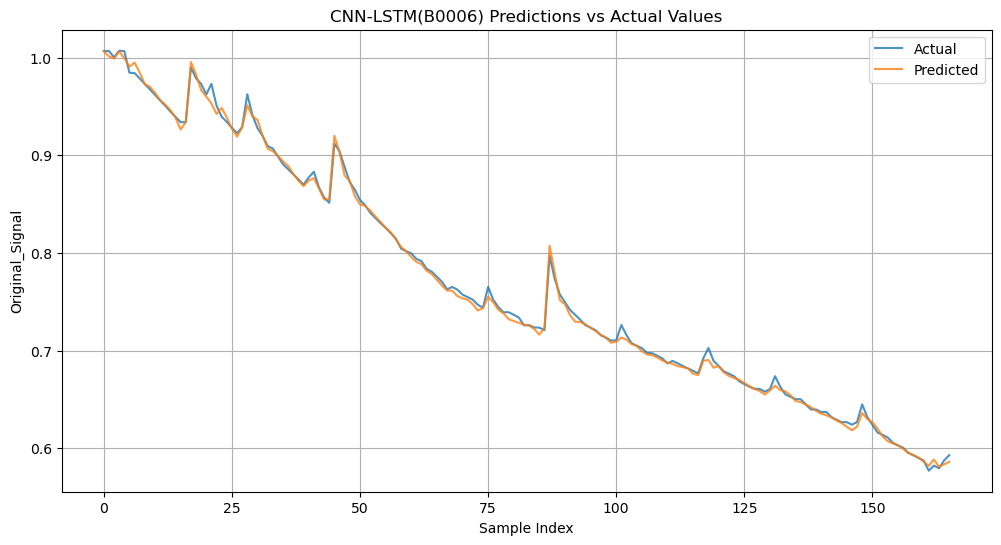


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [23]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-LSTM(B0006) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [24]:
#BOOO7

In [25]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [26]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [27]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data

In [28]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [29]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0006", "B0018"]
test_file = "B0007"

In [30]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [31]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [32]:
from tensorflow.keras.layers import Bidirectional
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN-BiLSTM model
    model = Sequential([
        # First CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                        input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Second CNN layer
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # 🔹 Replace LSTM with Bidirectional LSTM
        Bidirectional(LSTM(64, return_sequences=False, activation='relu')),
        
        # Dense output layer
        Dense(1)
    ])
    
    # Reshape input data for CNN-BiLSTM
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate on test set
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 0.1500 - val_loss: 0.0374
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0415 - val_loss: 0.0271
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0181 - val_loss: 0.0069
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0051 - val_loss: 0.0025
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0021 - val_loss: 0.0018
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0017 - val_loss: 9.9248e-04
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0012 - val_loss: 8.7291e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0011 - val_loss: 8.5814e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0010 - val_loss: 7.2452e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 9.4680e-04 - val_loss: 6.7935e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 8.8049e-04 - val_loss: 6.5053e-04
Epoch 12

In [33]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0021711095
Mean Squared Error (MSE): 0.0000098814
Root Mean Squared Error (RMSE): 0.0031434685
R2 Score: 0.9984408
Mean Absolute Percentage Error (MAPE): 0.2713381%


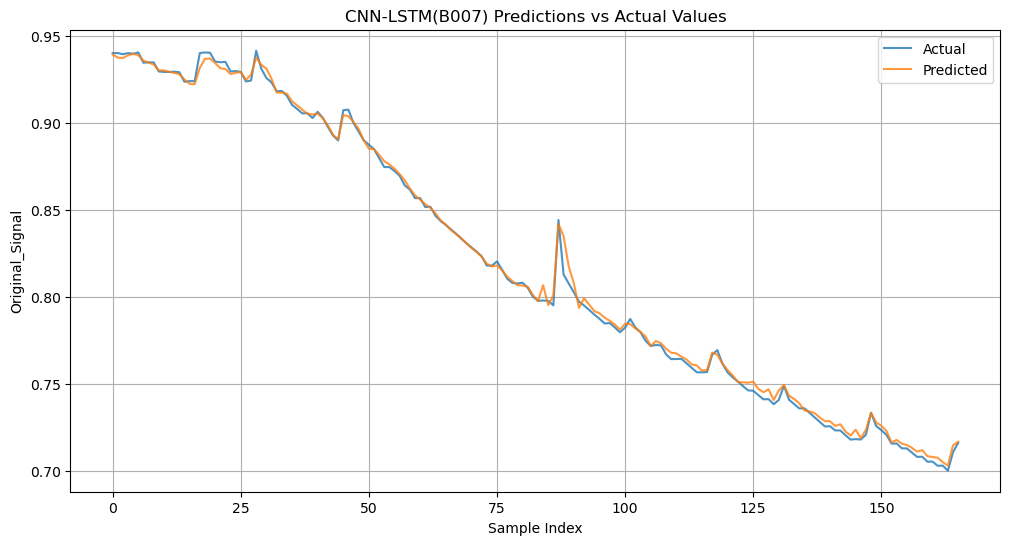


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [34]:
#Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-LSTM(B007) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [35]:
model.summary()
total_params = model.count_params()
print(f"Total trainable parameters in {model.name if hasattr(model, 'name') else 'model'}: {total_params:,}")


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ time_distributed_40           │ (None, 2, 4, 128)     │          256 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_41           │ (None, 2, 4, 128)     │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_42           │ (None, 2, 4, 128)     │       16,512 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_43           │ (None, 2, 4, 128)     │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_44           │ (None, 2, 512)        │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ bidirectional_8               │ (None, 128)           │      295,424 │
│ (Bidirectional)               │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_8 (Dense)               │ (None, 1)             │          129 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 936,965 (3.57 MB)

 Trainable params: 312,321 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 624,644 (2.38 MB)

Total trainable parameters in sequential_8: 312,321
